In [1]:
import json
import math
from datetime import datetime
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths (relative to this notebook's location) ──────────────────────────
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "result_analysis" else NOTEBOOK_DIR

RESULTS_FILE = PROJECT_ROOT / "result_bank" / "simulated_solver_results" / "UnitExperiment_1.json"
PLOTS_ROOT   = PROJECT_ROOT / "result_analysis" / "plots"

# ── Solver configuration ──────────────────────────────────────────────────
# Edit SOLVERS to control which solvers appear in every visualisation.
# The rest of the notebook adapts automatically.
#
#   All three:  SOLVERS = ["SQA", "SQA_SF", "SQA_DW"]
#   S1 vs S2:   SOLVERS = ["SQA", "SQA_SF"]
#
# SOLVERS = ["SQA", "SQA_SF", "SQA_DW"]
SOLVERS = ["SQA", "SQA_SF"]

SOLVER_LABELS = {"SQA": "S1 (Unit)", "SQA_SF": "S2 (Slack-Free)", "SQA_DW": "S3 (Domain-Wall)"}
SOLVER_COLORS = {"SQA": "#2196F3", "SQA_SF": "#4CAF50", "SQA_DW": "#FF9800"}
SOLVER_CMAPS  = {"SQA": "Blues",    "SQA_SF": "Greens",  "SQA_DW": "Oranges"}
ILP_COLOR = "#9C27B0"

n_solvers = len(SOLVERS)
panel_width = 6  # width in inches per solver panel

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# UnitSweep Benchmark Analysis

Comparison of three SQA formulations (S1, S2, S3) against an ILP baseline across the full Tier 1 grid (400 test cases).

- **S1 (Unit):** One-hot k-safety + binary slack storage (Trummer baseline with unit partitions)
- **S2 (Slack-Free):** One-hot k-safety + unbalanced penalty storage (no slack variables)
- **S3 (Domain-Wall):** Domain-wall k-safety + unbalanced penalty storage

In [2]:
with open(RESULTS_FILE) as f:
    data = json.load(f)

meta = data["metadata"]
rows = []

for key, entry in data["results"].items():
    n_nodes = entry["n_nodes"]
    n_parts = entry["n_partitions"]
    assign_vars = n_nodes * n_parts
    ilp = entry["solvers"]["ILP"]

    for sn in SOLVERS:
        s = entry["solvers"].get(sn)
        if s is None:
            continue  # solver not present in this entry (e.g. backfill incomplete)
        rows.append({
            "key": key,
            "n_nodes": n_nodes,
            "n_partitions": n_parts,
            "assign_vars": assign_vars,
            "solver": sn,
            "solver_label": SOLVER_LABELS[sn],
            "ilp_cost": ilp.get("cost"),
            "ilp_valid": ilp.get("valid", False),
            "cost": s.get("cost"),
            "valid": s.get("valid", False),
            "time_ms": s.get("time_ms"),
            "optimality_gap": s.get("optimality_gap"),
            "bqm_variables": s.get("bqm_variables"),
            "bqm_interactions": s.get("bqm_interactions"),
        })

df = pd.DataFrame(rows)

node_vals = sorted(df["n_nodes"].unique())
part_vals = sorted(df["n_partitions"].unique())
# Infer replicates from the data (cases per unique (n, p) combo)
combo_counts = df.groupby(["n_nodes", "n_partitions", "solver"]).size().reset_index(name="count")
z = combo_counts["count"].mode().iloc[0] if len(combo_counts) > 0 else "?"

# k_safety is per-entry; grab a representative value
k_safety_val = next(iter(data["results"].values()))["k_safety"]

print(f"Loaded {len(data['results'])} test cases  ({len(node_vals)} node sizes × {len(part_vals)} partition sizes × {z} replicates)")
print(f"Node counts:      {node_vals}")
print(f"Partition counts: {part_vals}")
print(f"SQA params:       num_reads={meta['num_reads']}, num_sweeps={meta['num_sweeps']}")
print(f"k_safety={k_safety_val}")
print(f"Analysing solvers: {', '.join(SOLVER_LABELS[s] for s in SOLVERS)}")
df.head(3 * n_solvers)

Loaded 400 test cases  (5 node sizes × 8 partition sizes × 10 replicates)
Node counts:      [np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9)]
Partition counts: [np.int64(3), np.int64(4), np.int64(8), np.int64(12), np.int64(18), np.int64(26), np.int64(36), np.int64(50)]
SQA params:       num_reads=1000, num_sweeps=1000
k_safety=2
Analysing solvers: S1 (Unit), S2 (Slack-Free)


,key,n_nodes,n_partitions,assign_vars,solver,solver_label,ilp_cost,ilp_valid,cost,valid,time_ms,optimality_gap,bqm_variables,bqm_interactions
0,n-2_p-12_1,2,12,24,SQA,S1 (Unit),0,True,0,True,15639.9,NaN,32,252
1,n-2_p-12_1,2,12,24,SQA_SF,S2 (Slack-Free),0,True,0,True,9631.2,NaN,24,144
2,n-2_p-12_10,2,12,24,SQA,S1 (Unit),0,True,0,True,15870.6,NaN,32,252
3,n-2_p-12_10,2,12,24,SQA_SF,S2 (Slack-Free),0,True,0,True,9684.0,NaN,24,144
4,n-2_p-12_2,2,12,24,SQA,S1 (Unit),0,True,0,True,15630.1,NaN,32,252
5,n-2_p-12_2,2,12,24,SQA_SF,S2 (Slack-Free),0,True,0,True,9642.6,NaN,24,144


## Helper Functions

In [3]:
def build_solver_grid(df, solver, value_col, agg="mean"):
    sub = df[df["solver"] == solver]
    pivot = sub.groupby(["n_nodes", "n_partitions"])[value_col].agg(agg).unstack("n_partitions")
    pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))
    return pivot


def heatmap(ax, grid, title, fmt=".2f", cmap="RdYlGn", vmin=None, vmax=None,
            cbar_label="", show_cbar=True):
    im = ax.imshow(grid.values, aspect="auto", cmap=cmap,
                   vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, fontsize=8)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index, fontsize=8)
    ax.set_xlabel("Partition Count", fontsize=9)
    ax.set_ylabel("Node Count", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    for r in range(len(grid.index)):
        for c in range(len(grid.columns)):
            val = grid.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, format(val, fmt), ha="center", va="center",
                        fontsize=7, color="black")
    if show_cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    return im

## 1. Validity Rate Heatmaps

Fraction of the 10 replicates at each (nodes, partitions) combination where the solver produced a constraint-satisfying solution. Green = 100% valid; red = frequent failures.

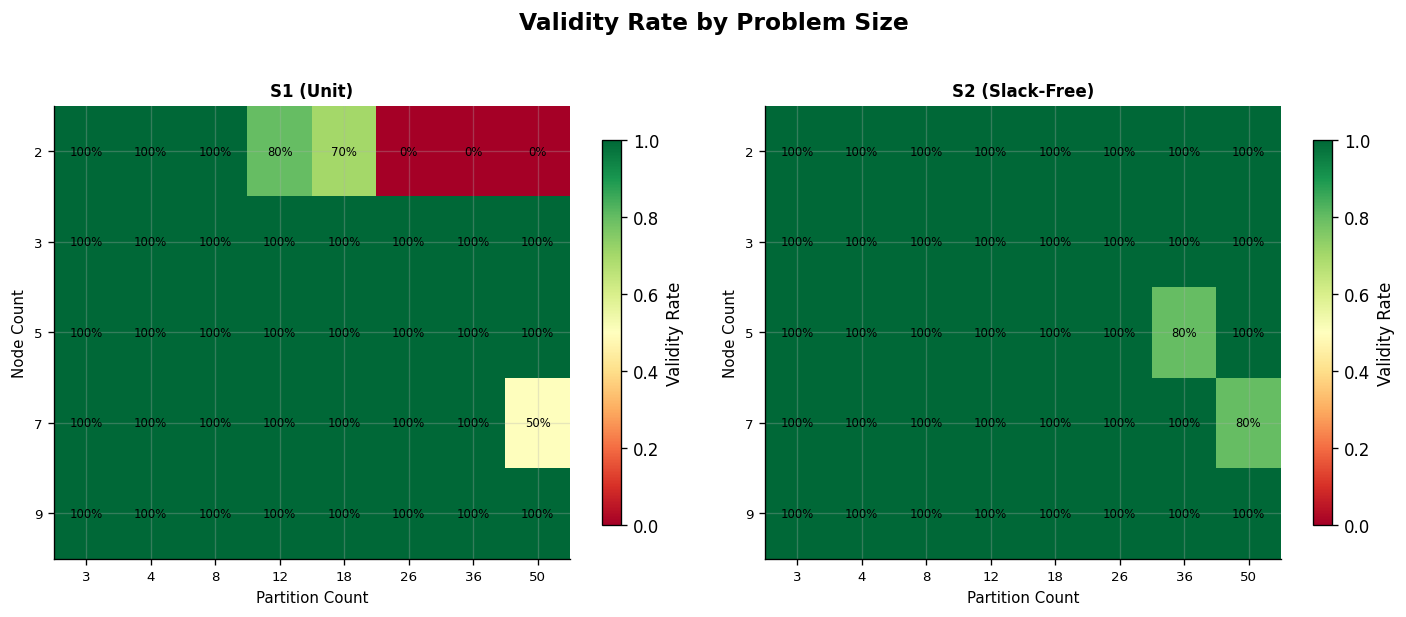

In [4]:
fig1, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig1.suptitle("Validity Rate by Problem Size", fontsize=14, fontweight="bold", y=1.02)

for ax, sn in zip(axes, SOLVERS):
    grid = build_solver_grid(df, sn, "valid", agg="mean")
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".0%", cmap="RdYlGn",
            vmin=0, vmax=1, cbar_label="Validity Rate")

fig1.tight_layout()
plt.show()

## 2. Optimality Gap Heatmaps

`(SQA cost - ILP cost) / ILP cost` averaged over valid replicates. Lower is better. Missing cells indicate no valid solutions at that size.

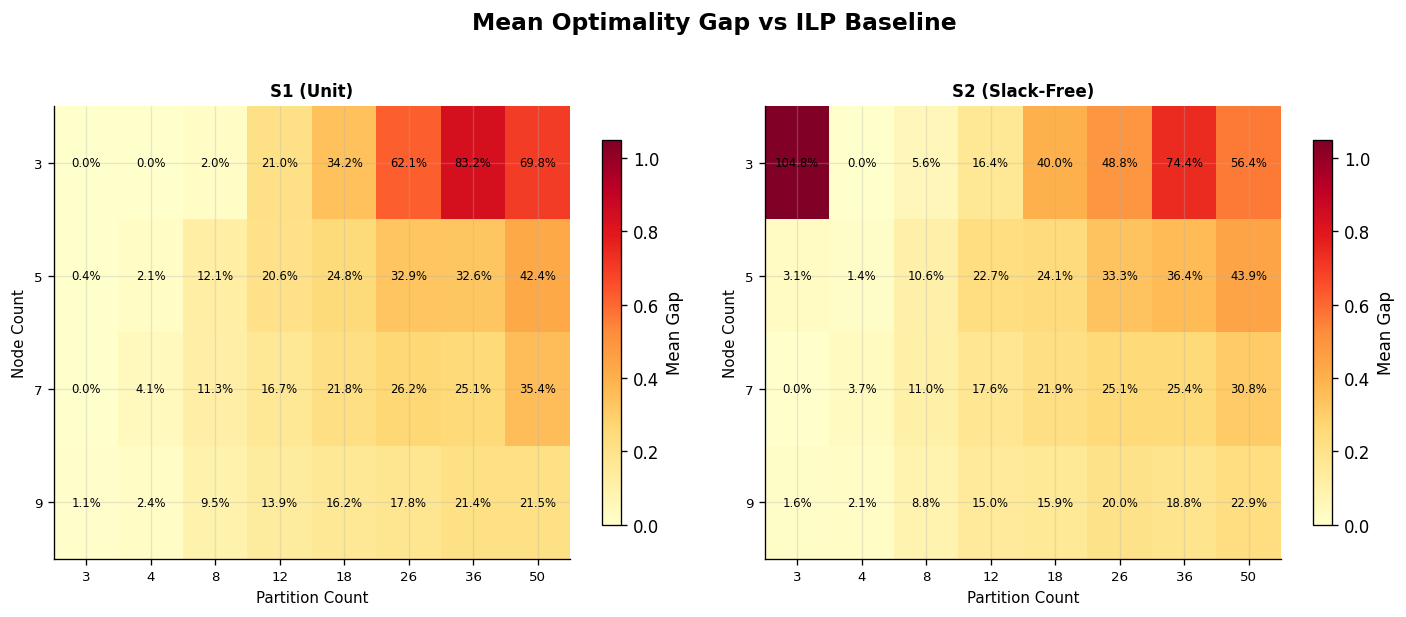

In [5]:
df_gap = df[df["valid"] & df["ilp_valid"]].dropna(subset=["optimality_gap"])

fig2, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig2.suptitle("Mean Optimality Gap vs ILP Baseline", fontsize=14, fontweight="bold", y=1.02)

# Find global max for consistent colour scale
all_grids = []
for sn in SOLVERS:
    g = build_solver_grid(df_gap, sn, "optimality_gap", agg="mean")
    all_grids.append(g)
vmax = max(g.max().max() for g in all_grids if not g.empty)

for ax, sn, grid in zip(axes, SOLVERS, all_grids):
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".1%", cmap="YlOrRd",
            vmin=0, vmax=vmax, cbar_label="Mean Gap")

fig2.tight_layout()
plt.show()

## 3. Solve Time Heatmaps
Mean SQA solve time in milliseconds. Reflects BQM size and interaction density. S3's doubled variable count should be visible as higher times.

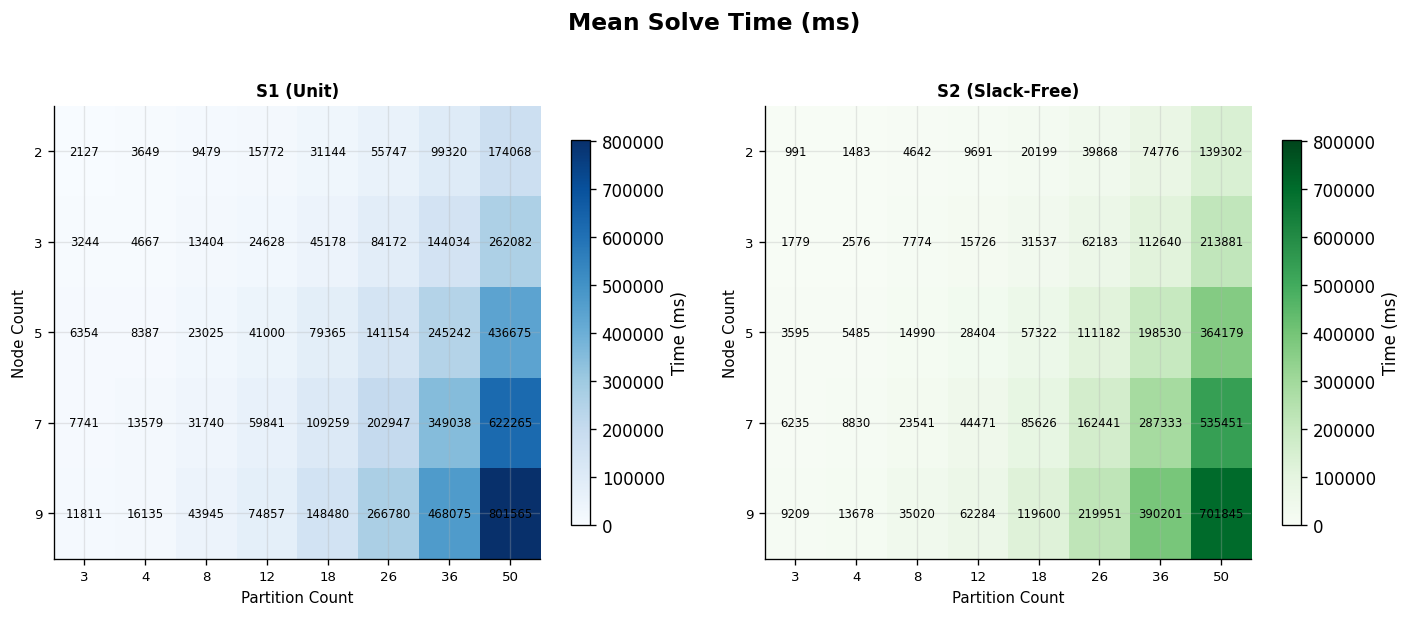

In [6]:
fig4, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
if n_solvers == 1: axes = [axes]
fig4.suptitle("Mean Solve Time (ms)", fontsize=14, fontweight="bold", y=1.02)

time_grids = [build_solver_grid(df, sn, "time_ms", agg="mean") for sn in SOLVERS]
vmax_t = max(g.max().max() for g in time_grids if not g.empty)

for ax, sn, grid in zip(axes, SOLVERS, time_grids):
    heatmap(ax, grid, SOLVER_LABELS[sn], fmt=".0f", cmap=SOLVER_CMAPS[sn],
            vmin=0, vmax=vmax_t, cbar_label="Time (ms)")

fig4.tight_layout()
plt.show()

## 4. BQM Size Comparison
Number of BQM variables and quadratic interactions for each solver at each problem size. S2 has the fewest variables (no slack); S3 has the most (wall variables double the count).

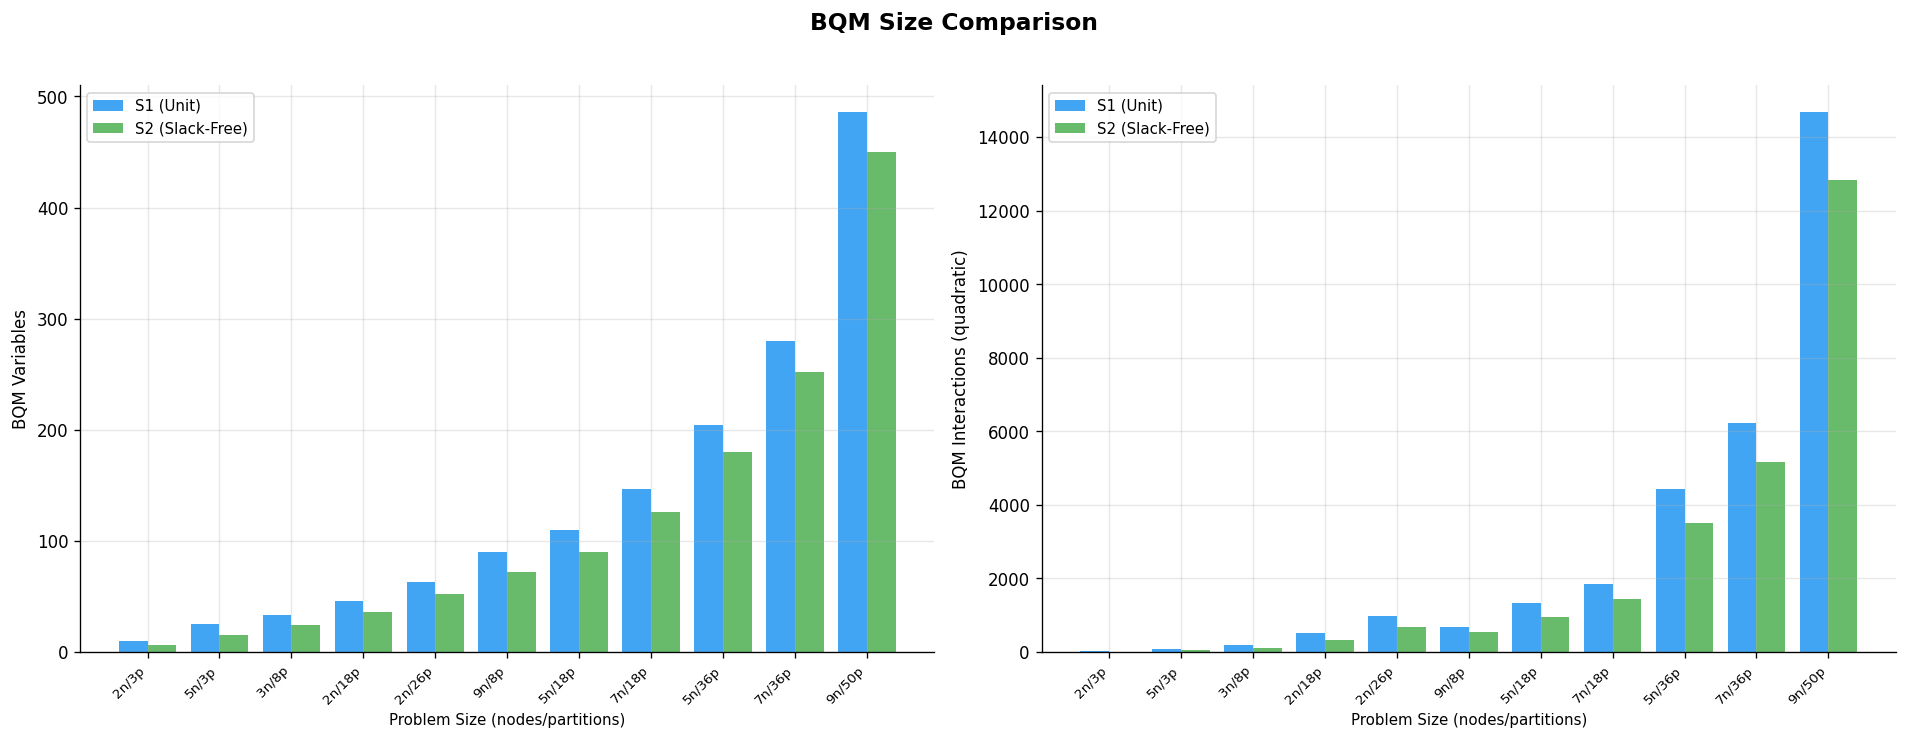

In [7]:
# One representative case per (n_nodes, n_partitions) — BQM size is deterministic
bqm_rows = []
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["bqm_variables"])
    rep = sub.drop_duplicates(subset=["n_nodes", "n_partitions"]).sort_values(["n_nodes", "n_partitions"])
    for _, row in rep.iterrows():
        bqm_rows.append({
            "size_label": f"{row['n_nodes']}n/{row['n_partitions']}p",
            "assign_vars": row["assign_vars"],
            "solver": sn,
            "bqm_variables": row["bqm_variables"],
            "bqm_interactions": row["bqm_interactions"],
        })

df_bqm = pd.DataFrame(bqm_rows)

# Filter to a readable subset (pick ~8 representative sizes)
unique_sizes = df_bqm.drop_duplicates("size_label").sort_values("assign_vars")
if len(unique_sizes) > 12:
    step = len(unique_sizes) // 10
    keep_labels = unique_sizes.iloc[::step]["size_label"].tolist()
    if unique_sizes.iloc[-1]["size_label"] not in keep_labels:
        keep_labels.append(unique_sizes.iloc[-1]["size_label"])
    df_bqm_plot = df_bqm[df_bqm["size_label"].isin(keep_labels)]
else:
    df_bqm_plot = df_bqm

fig5, (ax_v, ax_i) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle("BQM Size Comparison", fontsize=14, fontweight="bold", y=1.02)

size_labels_ordered = df_bqm_plot.drop_duplicates("size_label").sort_values("assign_vars")["size_label"].tolist()
x_pos = np.arange(len(size_labels_ordered))
bar_w = 0.8 / n_solvers

for panel_idx, (ax, col, ylabel) in enumerate([
    (ax_v, "bqm_variables", "BQM Variables"),
    (ax_i, "bqm_interactions", "BQM Interactions (quadratic)"),
]):
    for i, sn in enumerate(SOLVERS):
        offset = (i - (n_solvers - 1) / 2) * bar_w
        vals = []
        for sl in size_labels_ordered:
            row = df_bqm_plot[(df_bqm_plot["solver"] == sn) & (df_bqm_plot["size_label"] == sl)]
            vals.append(row[col].values[0] if len(row) > 0 else 0)
        ax.bar(x_pos + offset, vals, bar_w,
               label=SOLVER_LABELS[sn], color=SOLVER_COLORS[sn], alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(size_labels_ordered, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Problem Size (nodes/partitions)", fontsize=9)
    ax.legend(fontsize=9)

fig5.tight_layout()
plt.show()

## 5. Head-to-Head: Pairwise Gap Comparison
Each point is one test case where both solvers produced valid solutions. Points below the diagonal mean the x-axis solver had a better (lower) gap; above means the y-axis solver was better.

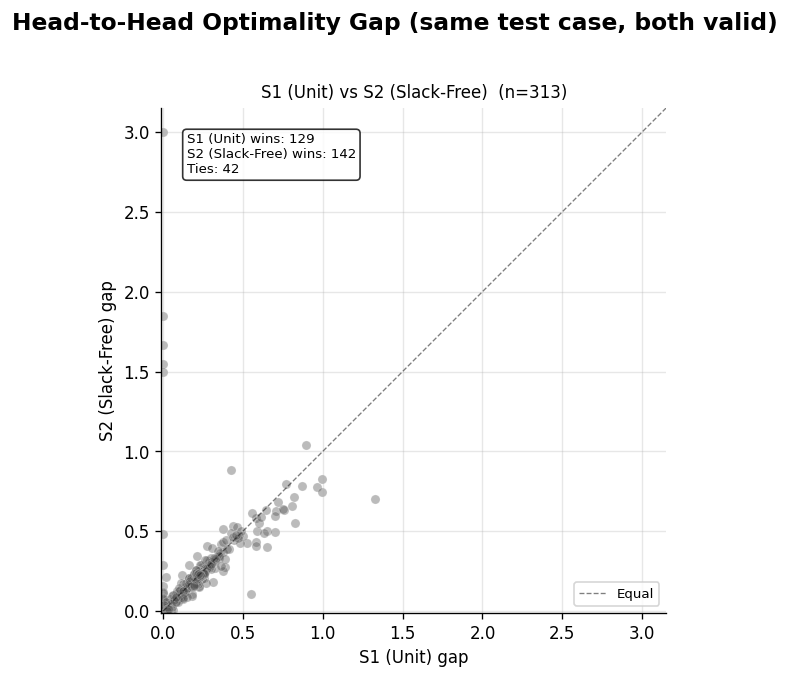

In [8]:
pairs = list(combinations(SOLVERS, 2))
n_pairs = len(pairs)

if n_pairs > 0:
    fig6, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5.5), squeeze=False)
    axes = axes.flatten()
    fig6.suptitle("Head-to-Head Optimality Gap (same test case, both valid)", fontsize=14, fontweight="bold", y=1.02)

    for ax, (a, b) in zip(axes, pairs):
        da = df_gap[df_gap["solver"] == a][["key", "optimality_gap"]].rename(columns={"optimality_gap": "gap_a"})
        db = df_gap[df_gap["solver"] == b][["key", "optimality_gap"]].rename(columns={"optimality_gap": "gap_b"})
        merged = da.merge(db, on="key", how="inner")

        if len(merged) > 0:
            ax.scatter(merged["gap_a"], merged["gap_b"],
                       alpha=0.4, s=30, color="#555555", edgecolors="white", linewidths=0.3)

            lim = max(merged["gap_a"].max(), merged["gap_b"].max()) * 1.05
            ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.5, label="Equal")
            ax.set_xlim(-0.01, lim)
            ax.set_ylim(-0.01, lim)

            a_wins = (merged["gap_a"] < merged["gap_b"]).sum()
            b_wins = (merged["gap_b"] < merged["gap_a"]).sum()
            ties = (merged["gap_a"] == merged["gap_b"]).sum()

            ax.text(0.05, 0.95,
                    f"{SOLVER_LABELS[a]} wins: {a_wins}\n"
                    f"{SOLVER_LABELS[b]} wins: {b_wins}\n"
                    f"Ties: {ties}",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

        ax.set_xlabel(f"{SOLVER_LABELS[a]} gap", fontsize=10)
        ax.set_ylabel(f"{SOLVER_LABELS[b]} gap", fontsize=10)
        ax.set_title(f"{SOLVER_LABELS[a]} vs {SOLVER_LABELS[b]}  (n={len(merged)})", fontsize=10)
        ax.legend(fontsize=8)
        ax.set_aspect("equal")

    fig6.tight_layout()
    plt.show()
else:
    fig6 = plt.figure()
    print("Only one solver selected — head-to-head comparison requires at least two.")

## 6. Validity Rate vs Partition Count
One panel per node count. Shows how each solver's ability to find feasible solutions degrades as the number of partitions grows.

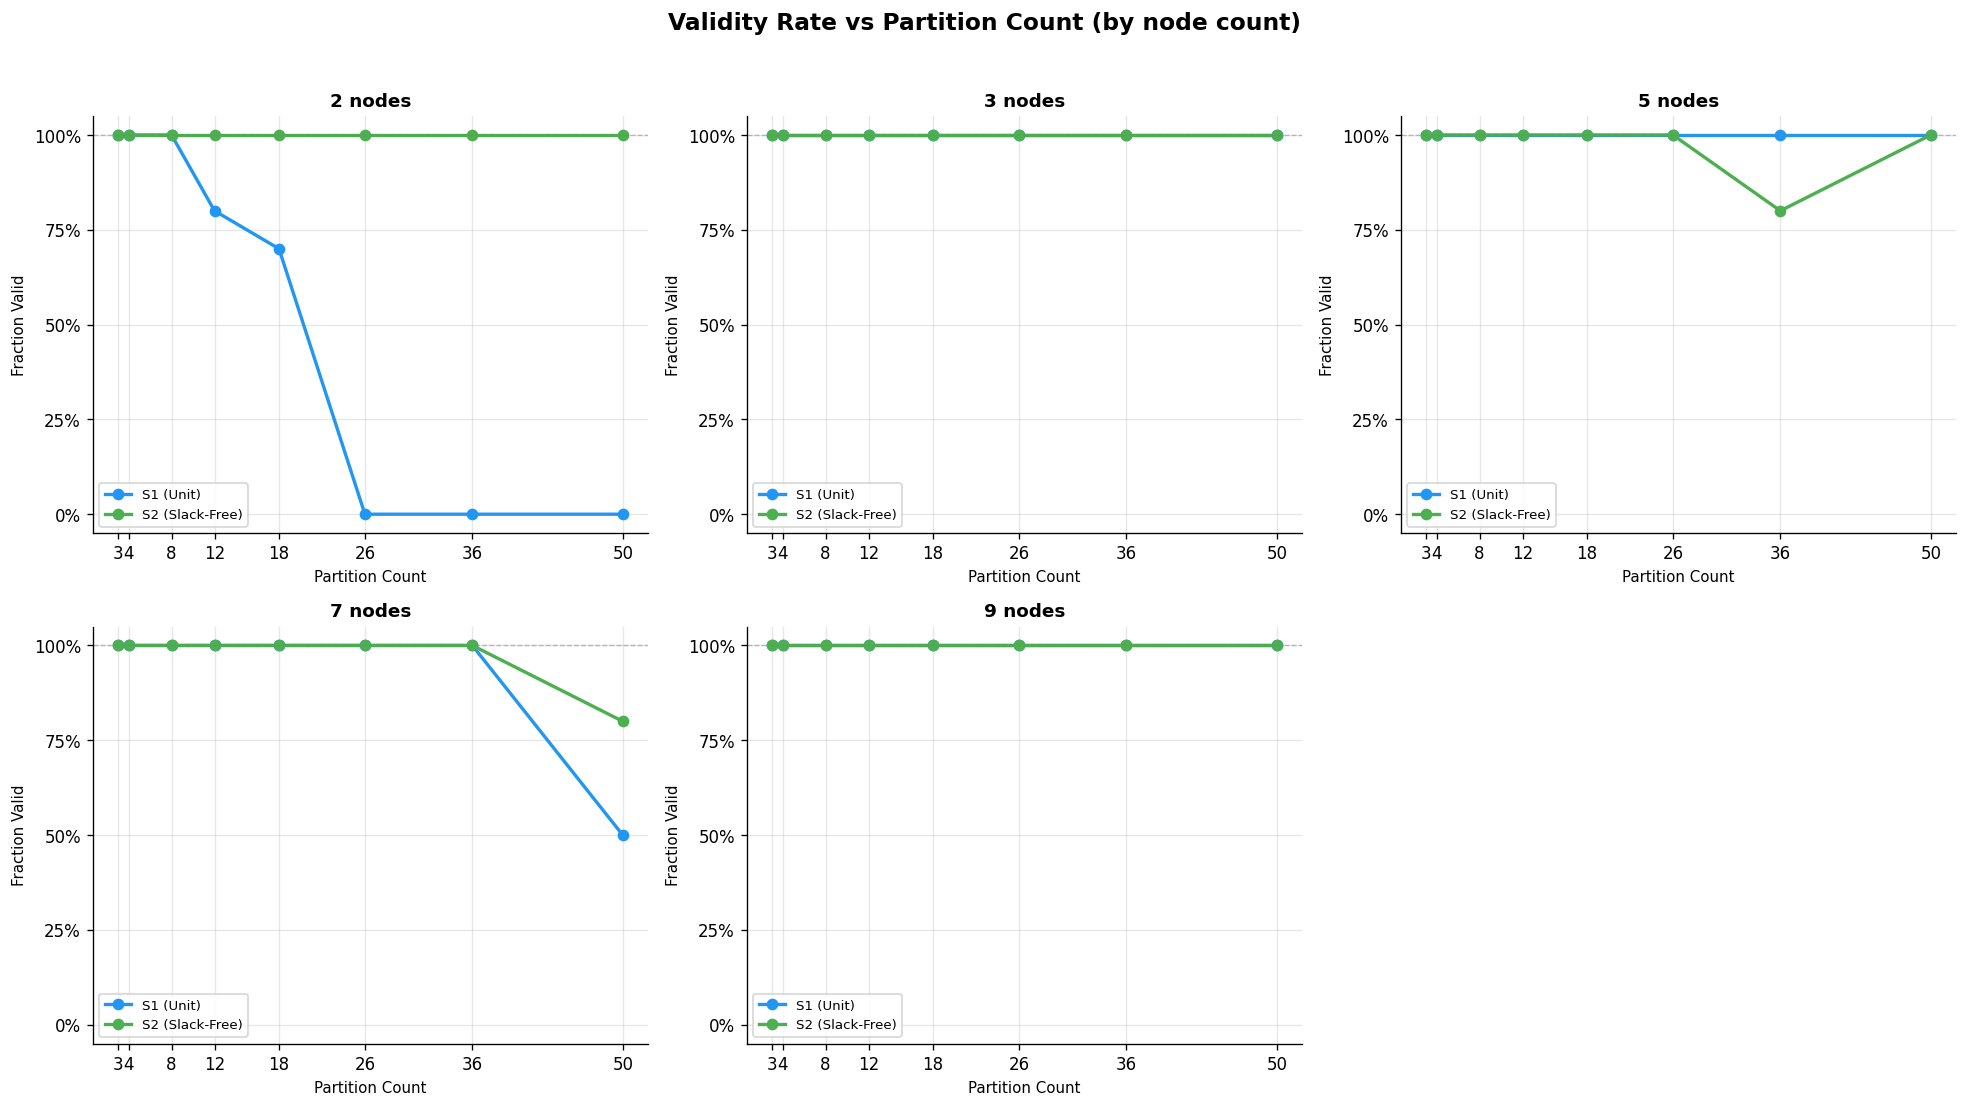

In [9]:
n_panels = len(node_vals)
ncols = min(n_panels, 3)
nrows = math.ceil(n_panels / ncols)

fig7, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)
fig7.suptitle("Validity Rate vs Partition Count (by node count)", fontsize=14, fontweight="bold", y=1.02)

validity = df.groupby(["n_nodes", "n_partitions", "solver"])["valid"].mean().reset_index()

for idx, n in enumerate(node_vals):
    ax = axes.flatten()[idx]
    for sn in SOLVERS:
        sub = validity[(validity["n_nodes"] == n) & (validity["solver"] == sn)].sort_values("n_partitions")
        ax.plot(sub["n_partitions"], sub["valid"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

    ax.set_title(f"{n} nodes", fontsize=11, fontweight="bold")
    ax.set_xlabel("Partition Count", fontsize=9)
    ax.set_ylabel("Fraction Valid", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xticks(sorted(sub["n_partitions"].unique()))
    ax.legend(fontsize=8)

for ax in axes.flatten()[n_panels:]:
    ax.set_visible(False)

fig7.tight_layout()
plt.show()

## 7. Scaling Analysis
Mean validity rate and mean optimality gap plotted against total assignment variables (|P| x |N|). Reveals the scaling cliff for each formulation.

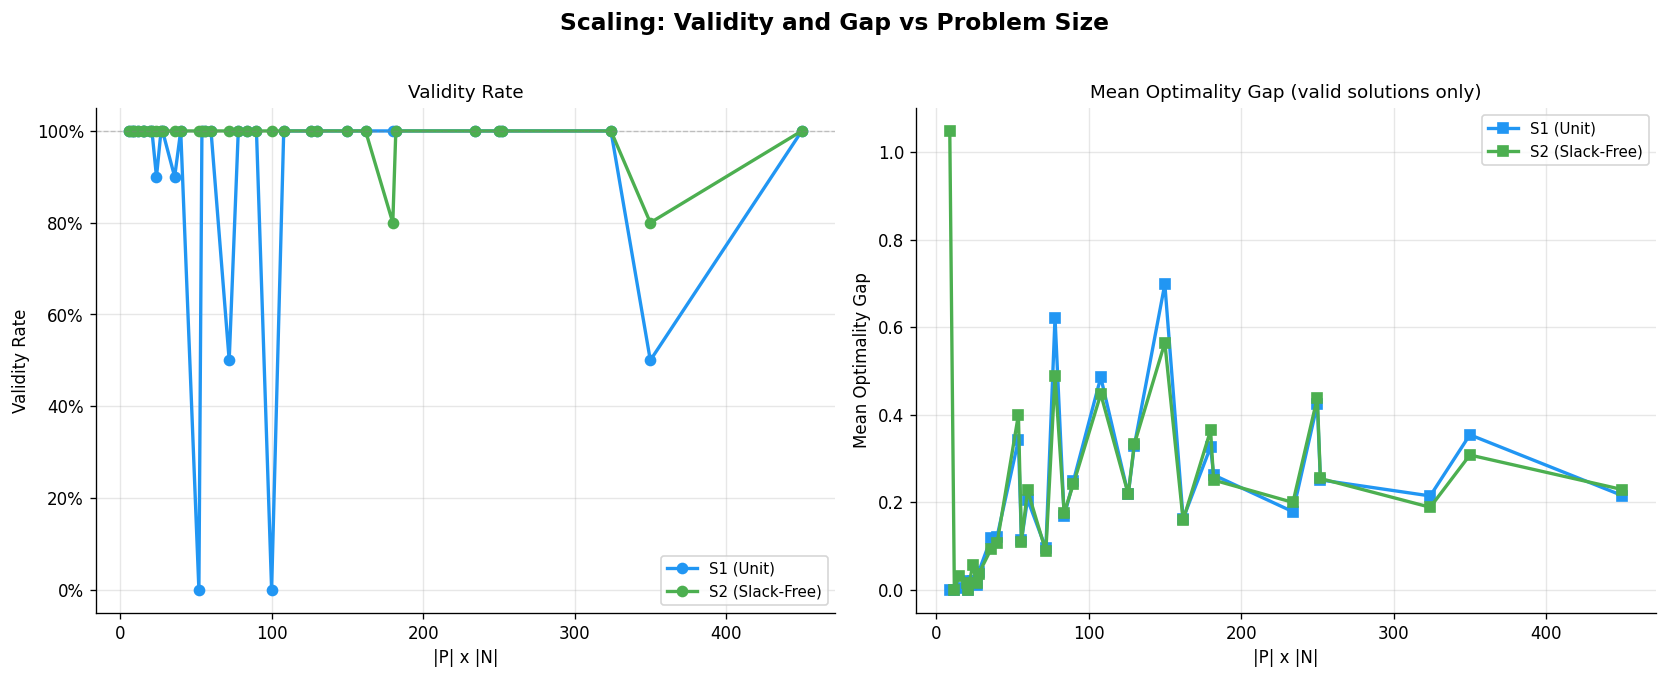

In [10]:
fig8, (ax_val, ax_gap) = plt.subplots(1, 2, figsize=(14, 5.5))
fig8.suptitle("Scaling: Validity and Gap vs Problem Size", fontsize=14, fontweight="bold", y=1.02)

scale_val = df.groupby(["assign_vars", "solver"])["valid"].mean().reset_index()
scale_gap = df_gap.groupby(["assign_vars", "solver"])["optimality_gap"].mean().reset_index()

for sn in SOLVERS:
    sv = scale_val[scale_val["solver"] == sn].sort_values("assign_vars")
    ax_val.plot(sv["assign_vars"], sv["valid"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

    sg = scale_gap[scale_gap["solver"] == sn].sort_values("assign_vars")
    ax_gap.plot(sg["assign_vars"], sg["optimality_gap"], "s-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=6,
                label=SOLVER_LABELS[sn])

ax_val.set_xlabel("|P| x |N|", fontsize=10)
ax_val.set_ylabel("Validity Rate", fontsize=10)
ax_val.set_ylim(-0.05, 1.05)
ax_val.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_val.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.4)
ax_val.legend(fontsize=9)
ax_val.set_title("Validity Rate", fontsize=11)

ax_gap.set_xlabel("|P| x |N|", fontsize=10)
ax_gap.set_ylabel("Mean Optimality Gap", fontsize=10)
ax_gap.legend(fontsize=9)
ax_gap.set_title("Mean Optimality Gap (valid solutions only)", fontsize=11)

fig8.tight_layout()
plt.show()

## 8. Aggregate Summary
Overall validity rate, mean gap, and mean solve time across all 400 test cases per solver.

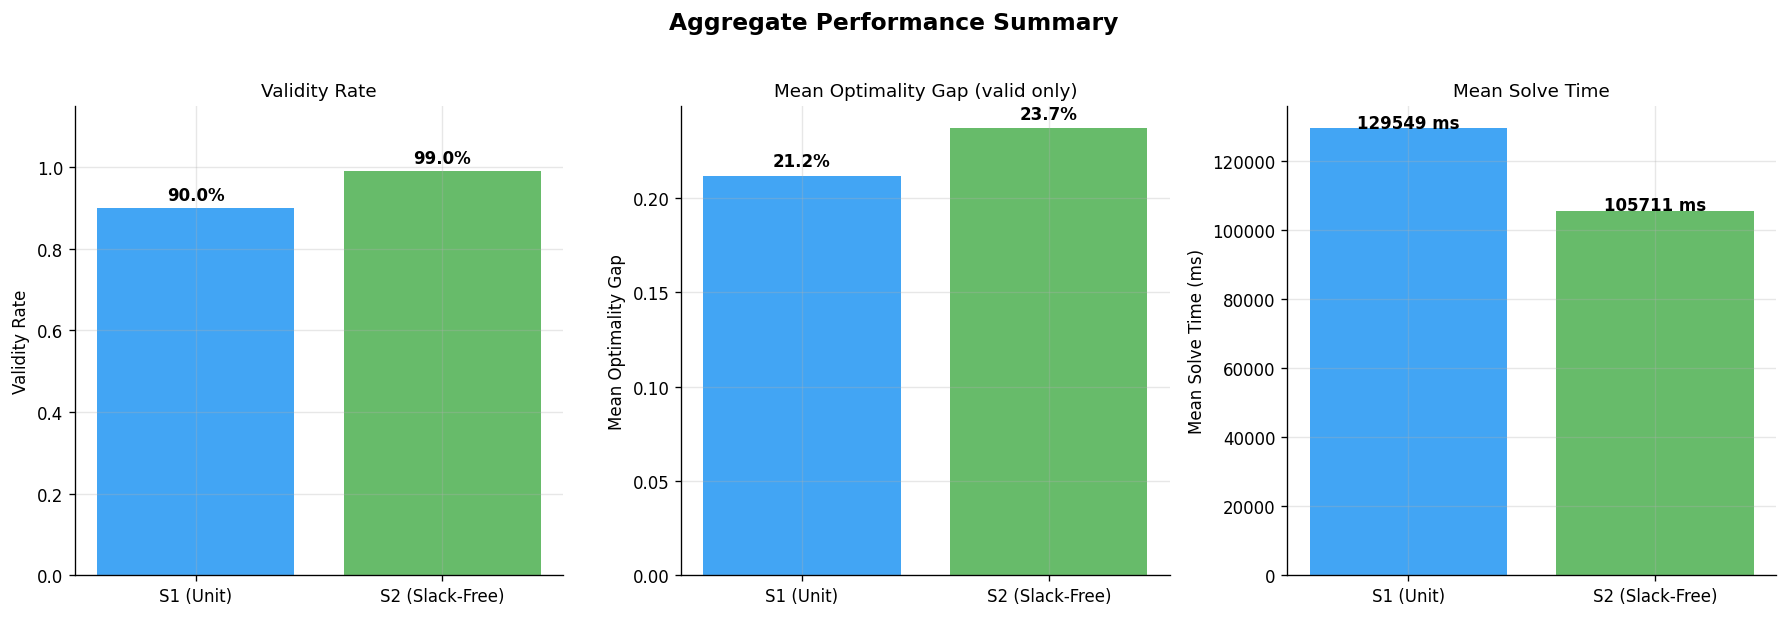

In [11]:
fig11, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig11.suptitle("Aggregate Performance Summary", fontsize=14, fontweight="bold", y=1.02)

# Validity
vals = [df[df["solver"] == sn]["valid"].mean() for sn in SOLVERS]
bars1 = ax1.bar([SOLVER_LABELS[sn] for sn in SOLVERS], vals,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars1, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
ax1.set_ylabel("Validity Rate", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title("Validity Rate", fontsize=11)

# Mean gap
gaps = [df_gap[df_gap["solver"] == sn]["optimality_gap"].mean() for sn in SOLVERS]
bars2 = ax2.bar([SOLVER_LABELS[sn] for sn in SOLVERS], gaps,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars2, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("Mean Optimality Gap", fontsize=10)
ax2.set_title("Mean Optimality Gap (valid only)", fontsize=11)

# Mean time
times = [df[df["solver"] == sn]["time_ms"].mean() for sn in SOLVERS]
bars3 = ax3.bar([SOLVER_LABELS[sn] for sn in SOLVERS], times,
                color=[SOLVER_COLORS[sn] for sn in SOLVERS], alpha=0.85)
for bar, v in zip(bars3, times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{v:.0f} ms", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylabel("Mean Solve Time (ms)", fontsize=10)
ax3.set_title("Mean Solve Time", fontsize=11)

fig11.tight_layout()
plt.show()

## 9. Physical Qubit Requirements Across D-Wave Topologies

To run these QUBO formulations on real quantum hardware, each logical variable must be embedded into the hardware's connectivity graph via **minor embedding**. Logical variables with more connections than the hardware's qubit degree require **chains** of physical qubits, inflating the total qubit cost.

Three D-Wave chip families are considered:

| Chip | Topology | Qubits | Degree |
|---|---|---|---|
| DW 2000Q | Chimera C16 | 2,048 | 6 |
| Advantage | Pegasus P16 | 5,640 | 15 |
| Advantage2 | Zephyr Z15 | 7,440 | 20 |

Higher qubit degree means each physical qubit can represent more interactions natively, reducing chain lengths and total qubit consumption. The **degree-based lower bound** gives the minimum possible physical qubits:

    LB = num_vars × max(1, ⌈max_degree / hw_degree⌉)

This section builds BQMs for one representative test case at each grid point, extracts the interaction graph statistics, and computes lower bounds for all three topologies.

In [12]:
import math

# D-Wave hardware catalogue
HW_CHIPS = {
    "DW_2000Q":   {"label": "DW 2000Q (Chimera)",   "degree": 6,  "qubits": 2048},
    "Advantage":  {"label": "Advantage (Pegasus)",   "degree": 15, "qubits": 5640},
    "Advantage2": {"label": "Advantage2 (Zephyr)",   "degree": 20, "qubits": 7440},
}

def degree_lb(num_vars, max_deg, hw_deg):
    if num_vars == 0 or hw_deg == 0:
        return num_vars
    return num_vars * max(1, math.ceil(max_deg / hw_deg))

# ── Analytical max-degree formulas ──────────────────────────────────────
# Derived from the QUBO structure of each formulation:
#
# S1 (unit + binary slack):
#   A_{pn} degree: (|N|-1) k-safety + (|P|-1) storage + slack_bits_n
#   S_{n,i} degree: |P| + (slack_bits_n - 1)
#   Mersenne capacity C = 2^k-1  =>  slack_bits = k = C.bit_length()
#
# S2 (slack-free):
#   A_{pn} degree: (|N|-1) k-safety + (|P|-1) storage
#   max_degree = |N| + |P| - 2
#
# S3 (domain-wall):
#   Linking (sum A = sum W)^2 creates all-to-all among {A_{p,*}, W_{p,*}}
#   A_{pn}: (|N|-1) + |N| linking + (|P|-1) storage = 2|N| + |P| - 2
#   W_{p,j}: |N| + (|N|-1) linking = 2|N| - 1
#   max_degree = 2|N| + |P| - 2  (A vars dominate)

def _round_up_to_mersenne(c):
    return (1 << c.bit_length()) - 1

def compute_qubit_stats_analytical(n_nodes, n_partitions, k_safety=2, capacity_factor=1.3):
    import random
    rng = random.Random(42)

    N, P = n_nodes, n_partitions

    # Estimate Mersenne capacities (same logic as generate_unit_test_case)
    min_cap = -(-k_safety * P // N)
    min_cap = max(min_cap, 1)
    caps = []
    for _ in range(N):
        raw = int(min_cap * rng.uniform(1.0, capacity_factor))
        raw = max(raw, min_cap)
        caps.append(_round_up_to_mersenne(raw))
    max_slack_bits = max(c.bit_length() for c in caps)

    rows = []
    for sn in SOLVERS:
        if sn == "SQA":
            total_slack = sum(c.bit_length() for c in caps)
            bqm_vars = P * N + total_slack
            max_deg = max(
                (N - 1) + (P - 1) + max_slack_bits,   # A var
                P + max_slack_bits - 1,                 # S var
            )
            bqm_ints = P * N*(N-1)//2
            for c in caps:
                sb = c.bit_length()
                bqm_ints += (P + sb) * (P + sb - 1) // 2

        elif sn == "SQA_SF":
            bqm_vars = P * N
            max_deg = (N - 1) + (P - 1)
            bqm_ints = P * N*(N-1)//2 + N * P*(P-1)//2

        elif sn == "SQA_DW":
            bqm_vars = 2 * P * N
            max_deg = max(
                (N - 1) + N + (P - 1),   # A var: 2N + P - 2
                N + (N - 1),               # W var: 2N - 1
            )
            bqm_ints = P * (2*N)*(2*N-1)//2 + N * P*(P-1)//2 + P*(N-1)

        row = {
            "n_nodes": n_nodes,
            "n_partitions": n_partitions,
            "assign_vars": N * P,
            "solver": sn,
            "bqm_vars": bqm_vars,
            "bqm_interactions": bqm_ints,
            "max_degree": max_deg,
        }

        for chip_name, chip in HW_CHIPS.items():
            lb = degree_lb(bqm_vars, max_deg, chip["degree"])
            row[f"lb_{chip_name}"] = lb
            row[f"fits_{chip_name}"] = lb <= chip["qubits"]
            row[f"chain_lb_{chip_name}"] = max(1, math.ceil(max_deg / chip["degree"]))

        rows.append(row)
    return rows

# Compute for every grid point -- instant, no BQM construction needed
qubit_rows = []
for n_nodes in node_vals:
    for n_parts in part_vals:
        qubit_rows.extend(compute_qubit_stats_analytical(n_nodes, n_parts))

df_qubit = pd.DataFrame(qubit_rows)
print(f"Computed qubit stats for {len(df_qubit)} (size, solver) combinations  [analytical]")
df_qubit.head(9)

Computed qubit stats for 80 (size, solver) combinations  [analytical]


,n_nodes,n_partitions,assign_vars,solver,bqm_vars,bqm_interactions,max_degree,lb_DW_2000Q,fits_DW_2000Q,chain_lb_DW_2000Q,lb_Advantage,fits_Advantage,chain_lb_Advantage,lb_Advantage2,fits_Advantage2,chain_lb_Advantage2
0,2,3,6,SQA,10,23,5,10,True,1,10,True,1,10,True,1
1,2,3,6,SQA_SF,6,9,3,6,True,1,6,True,1,6,True,1
2,2,4,8,SQA,14,46,7,28,True,2,14,True,1,14,True,1
3,2,4,8,SQA_SF,8,16,4,8,True,1,8,True,1,8,True,1
4,2,8,16,SQA,24,140,12,48,True,2,24,True,1,24,True,1
5,2,8,16,SQA_SF,16,64,8,32,True,2,16,True,1,16,True,1
6,2,12,24,SQA,32,252,16,96,True,3,64,True,2,32,True,1
7,2,12,24,SQA_SF,24,144,12,48,True,2,24,True,1,24,True,1
8,2,18,36,SQA,46,524,23,184,True,4,92,True,2,92,True,2


### 9a. Physical Qubit Lower Bounds — Heatmaps

Degree-based lower bound on physical qubits needed for each (nodes, partitions) combination, shown per solver and per D-Wave topology. Cells exceeding the chip's qubit capacity are marked.

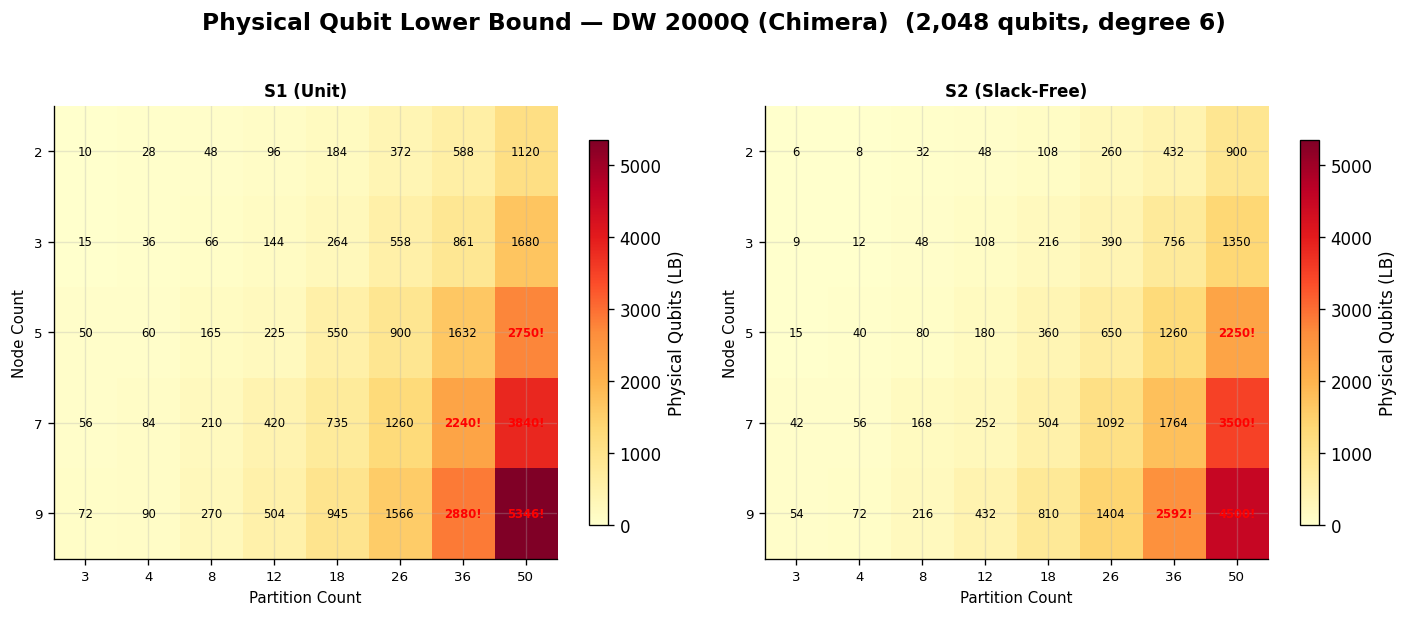

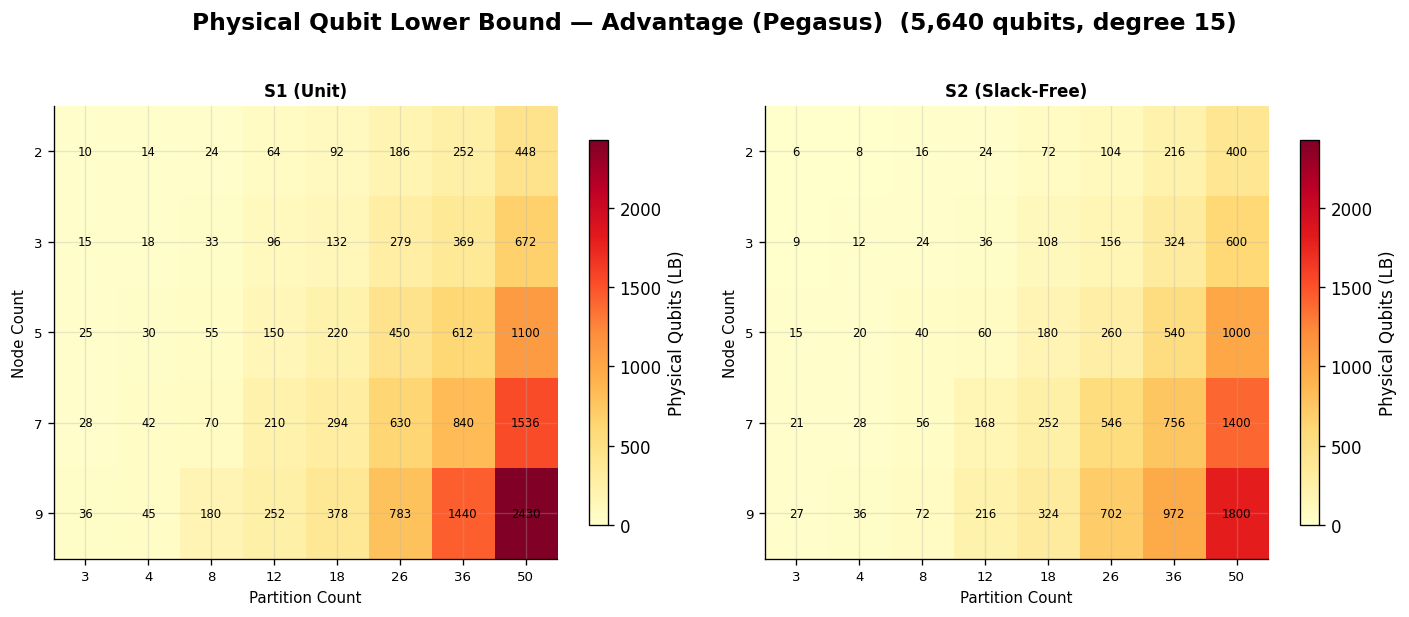

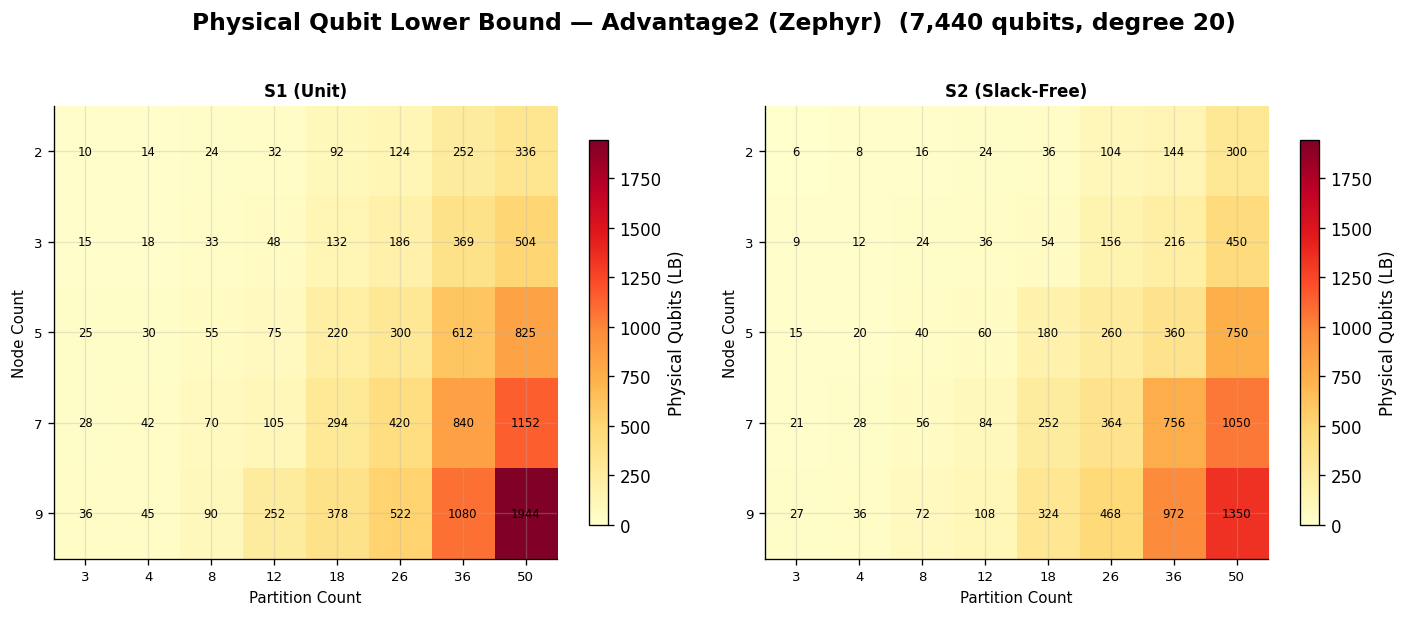

In [13]:
chip_names = list(HW_CHIPS.keys())

for chip_name in chip_names:
    chip = HW_CHIPS[chip_name]
    fig_q, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 5))
    if n_solvers == 1: axes = [axes]
    fig_q.suptitle(f"Physical Qubit Lower Bound — {chip['label']}  ({chip['qubits']:,} qubits, degree {chip['degree']})",
                   fontsize=14, fontweight="bold", y=1.02)

    col = f"lb_{chip_name}"
    vmax_q = df_qubit[col].max()

    for ax, sn in zip(axes, SOLVERS):
        sub = df_qubit[df_qubit["solver"] == sn]
        pivot = sub.pivot_table(index="n_nodes", columns="n_partitions", values=col, aggfunc="first")
        pivot = pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))

        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax_q, origin="upper")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_xlabel("Partition Count", fontsize=9)
        ax.set_ylabel("Node Count", fontsize=9)
        ax.set_title(SOLVER_LABELS[sn], fontsize=10, fontweight="bold")

        for r in range(len(pivot.index)):
            for c in range(len(pivot.columns)):
                val = pivot.values[r, c]
                if not np.isnan(val):
                    color = "red" if val > chip["qubits"] else "black"
                    marker = "!" if val > chip["qubits"] else ""
                    ax.text(c, r, f"{int(val)}{marker}", ha="center", va="center",
                            fontsize=7, color=color, fontweight="bold" if marker else "normal")

        plt.colorbar(im, ax=ax, label="Physical Qubits (LB)", shrink=0.85)

    fig_q.tight_layout()
    plt.show()

### 9b. Qubit Requirements Comparison — Largest Problem Sizes

Bar chart comparing the degree-based physical qubit lower bound across all three topologies for the largest problem sizes in the grid. Shows how sparser hardware topologies (Chimera) inflate qubit requirements compared to denser ones (Zephyr).

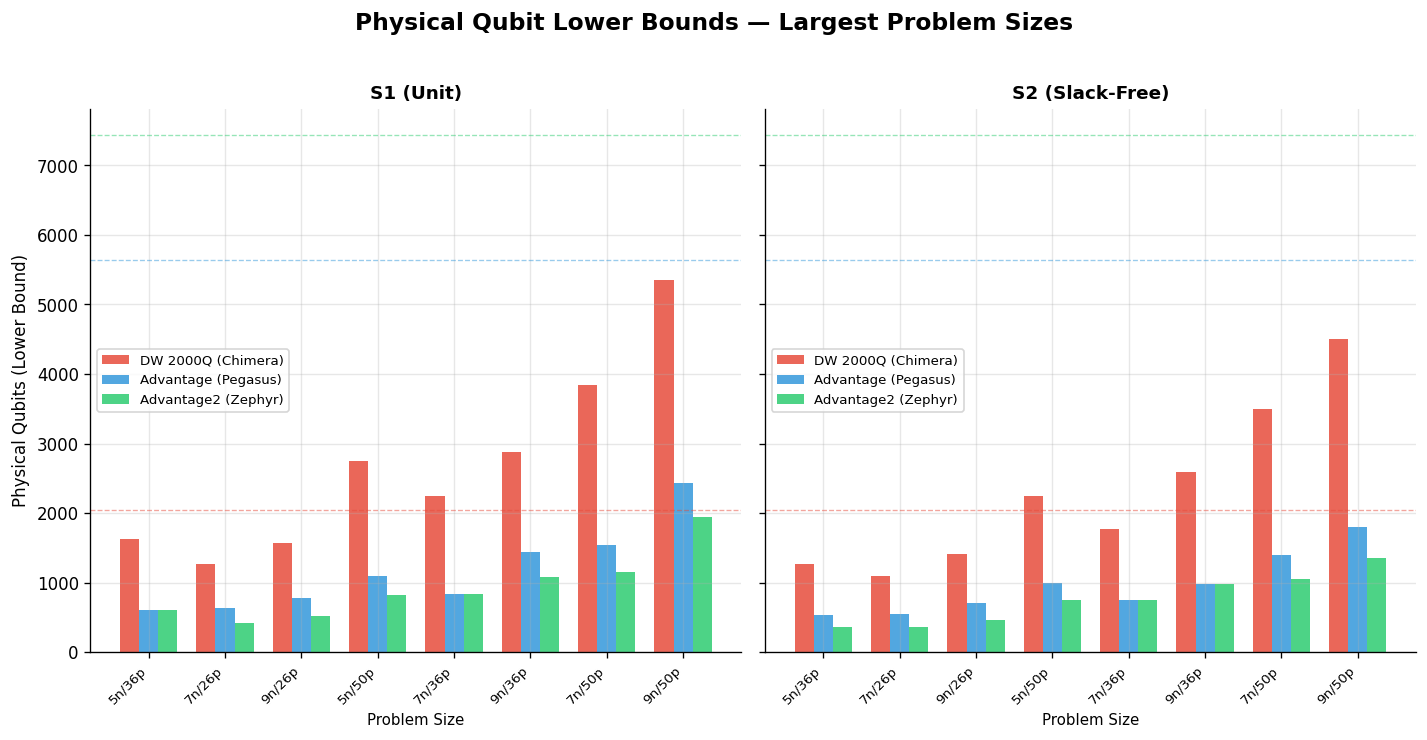

In [14]:
# Pick the 8 largest problem sizes
large_sizes = df_qubit.drop_duplicates(["n_nodes", "n_partitions"]).nlargest(8, "assign_vars")
large_combos = list(zip(large_sizes["n_nodes"], large_sizes["n_partitions"]))

fig_qbar, axes = plt.subplots(1, n_solvers, figsize=(panel_width * n_solvers, 6), sharey=True)
if n_solvers == 1: axes = [axes]
fig_qbar.suptitle("Physical Qubit Lower Bounds — Largest Problem Sizes", fontsize=14, fontweight="bold", y=1.02)

chip_colors = {"DW_2000Q": "#e74c3c", "Advantage": "#3498db", "Advantage2": "#2ecc71"}

for ax, sn in zip(axes, SOLVERS):
    sub = df_qubit[df_qubit["solver"] == sn]
    sub = sub[sub.apply(lambda r: (r["n_nodes"], r["n_partitions"]) in large_combos, axis=1)]
    sub = sub.sort_values("assign_vars")

    labels = [f"{r['n_nodes']}n/{r['n_partitions']}p" for _, r in sub.iterrows()]
    x = np.arange(len(labels))
    w = 0.25

    for i, (chip_name, chip) in enumerate(HW_CHIPS.items()):
        vals = sub[f"lb_{chip_name}"].values
        bars = ax.bar(x + (i-1)*w, vals, w, label=chip["label"],
                      color=chip_colors[chip_name], alpha=0.85)
        # Draw capacity line
        ax.axhline(chip["qubits"], color=chip_colors[chip_name], linestyle="--",
                   linewidth=0.8, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(SOLVER_LABELS[sn], fontsize=11, fontweight="bold")
    ax.set_xlabel("Problem Size", fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel("Physical Qubits (Lower Bound)", fontsize=10)
    ax.legend(fontsize=8)

fig_qbar.tight_layout()
plt.show()

### 9c. BQM Maximum Degree Scaling

The maximum degree of the interaction graph determines chain length requirements. S3's domain-wall linking constraint creates denser connectivity than S1/S2's one-hot encoding. S2 benefits from having fewer variables despite similar connectivity per variable.

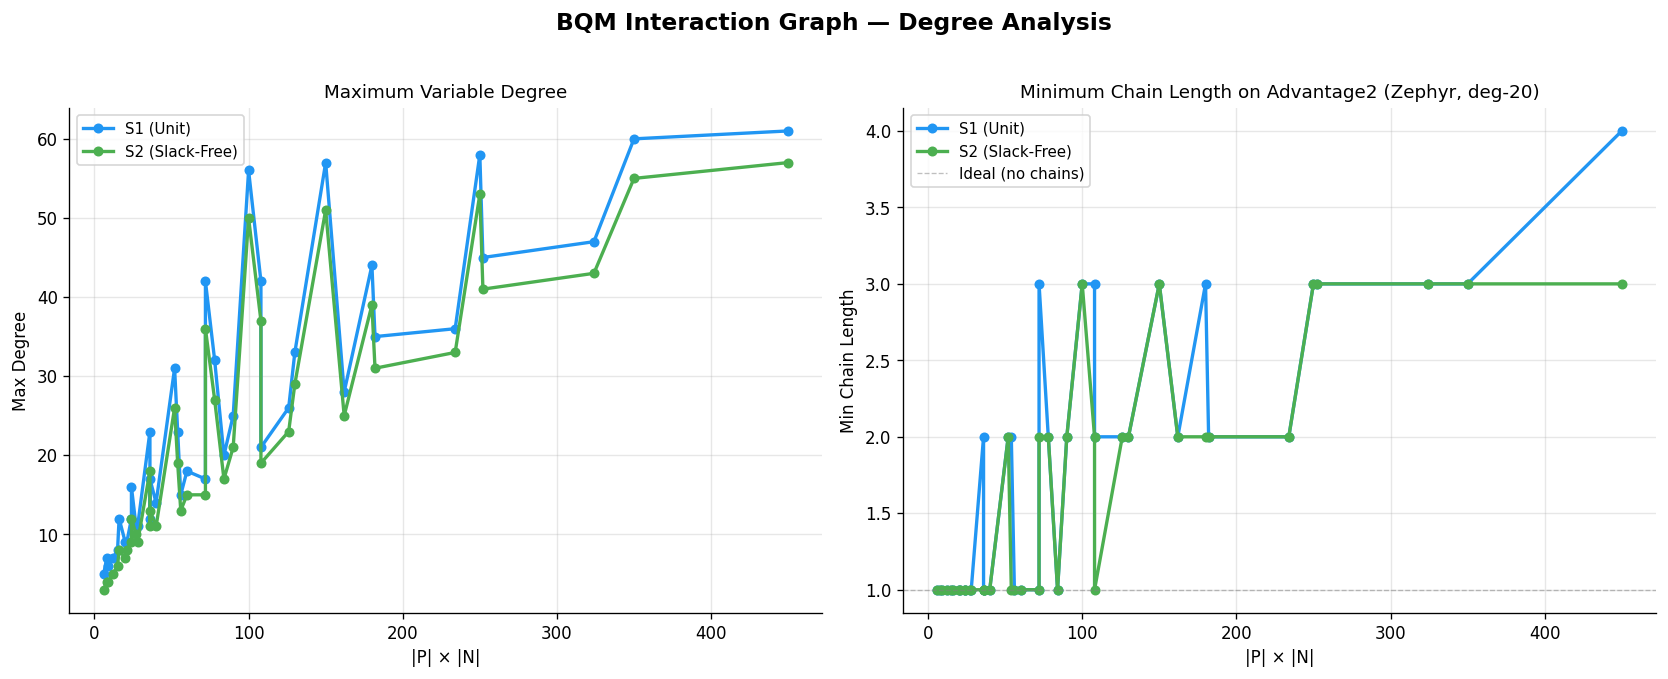

In [15]:
fig_deg, (ax_deg, ax_ratio) = plt.subplots(1, 2, figsize=(14, 5.5))
fig_deg.suptitle("BQM Interaction Graph — Degree Analysis", fontsize=14, fontweight="bold", y=1.02)

for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    ax_deg.plot(sub["assign_vars"], sub["max_degree"], "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                label=SOLVER_LABELS[sn])

ax_deg.set_xlabel("|P| × |N|", fontsize=10)
ax_deg.set_ylabel("Max Degree", fontsize=10)
ax_deg.set_title("Maximum Variable Degree", fontsize=11)
ax_deg.legend(fontsize=9)

# Chain length multiplier for each topology
for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    # Advantage2 chain LB = ceil(max_deg / 20)
    chain_lb = np.ceil(sub["max_degree"].values / 20).astype(int)
    ax_ratio.plot(sub["assign_vars"], chain_lb, "o-",
                  color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                  label=SOLVER_LABELS[sn])

ax_ratio.set_xlabel("|P| × |N|", fontsize=10)
ax_ratio.set_ylabel("Min Chain Length", fontsize=10)
ax_ratio.set_title("Minimum Chain Length on Advantage2 (Zephyr, deg-20)", fontsize=11)
ax_ratio.axhline(1, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="Ideal (no chains)")
ax_ratio.legend(fontsize=9)

fig_deg.tight_layout()
plt.show()

### 9d. Hardware Feasibility Summary

For each (solver, topology) pair, the largest problem size whose qubit lower bound fits within the chip's capacity. This represents the theoretical maximum problem size each formulation can handle on each hardware platform — the actual limit will be somewhat smaller due to embedding overhead.

In [16]:
# Find max embeddable size per (solver, chip)
feasibility = []
for sn in SOLVERS:
    sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
    row = {"Solver": SOLVER_LABELS[sn]}
    for chip_name, chip in HW_CHIPS.items():
        fits = sub[sub[f"fits_{chip_name}"]]
        if len(fits) > 0:
            best = fits.iloc[-1]
            row[chip["label"]] = f"{int(best['n_nodes'])}n/{int(best['n_partitions'])}p ({int(best['assign_vars'])} vars → {int(best[f'lb_{chip_name}'])} qubits)"
        else:
            row[chip["label"]] = "None fit"
    feasibility.append(row)

df_feas = pd.DataFrame(feasibility).set_index("Solver")
print("Largest problem size fitting on each chip (by degree lower bound):\n")
df_feas

Largest problem size fitting on each chip (by degree lower bound):



,DW 2000Q (Chimera),Advantage (Pegasus),Advantage2 (Zephyr)
Solver,,,
S1 (Unit),9n/26p (234 vars → 1566 qubits),9n/50p (450 vars → 2430 qubits),9n/50p (450 vars → 1944 qubits)
S2 (Slack-Free),7n/36p (252 vars → 1764 qubits),9n/50p (450 vars → 1800 qubits),9n/50p (450 vars → 1350 qubits)


### 9e. Qubit Overhead Ratio

Physical-to-logical qubit ratio (lower bound) across problem sizes, showing how efficiently each formulation uses hardware resources. A ratio of 1.0 means each logical variable maps to exactly one physical qubit (ideal). Higher ratios indicate more chain overhead.

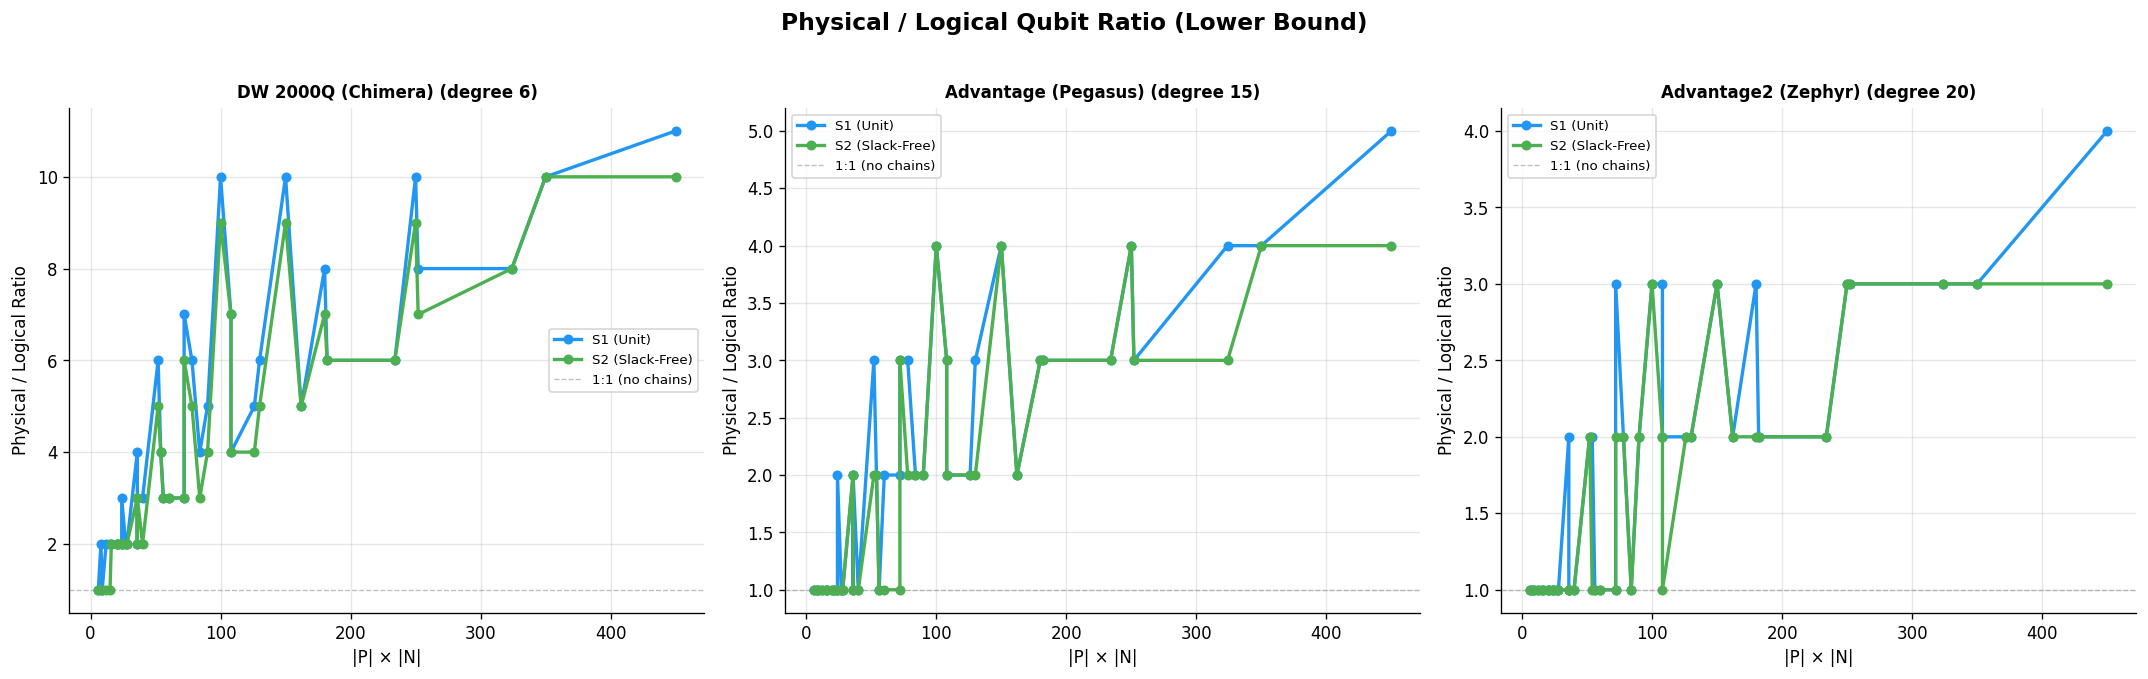

In [17]:
fig_eff, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig_eff.suptitle("Physical / Logical Qubit Ratio (Lower Bound)", fontsize=14, fontweight="bold", y=1.02)

for ax, (chip_name, chip) in zip(axes, HW_CHIPS.items()):
    for sn in SOLVERS:
        sub = df_qubit[df_qubit["solver"] == sn].sort_values("assign_vars")
        ratio = sub[f"lb_{chip_name}"] / sub["bqm_vars"]
        ax.plot(sub["assign_vars"], ratio, "o-",
                color=SOLVER_COLORS[sn], linewidth=2, markersize=5,
                label=SOLVER_LABELS[sn])

    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="1:1 (no chains)")
    ax.set_xlabel("|P| × |N|", fontsize=10)
    ax.set_ylabel("Physical / Logical Ratio", fontsize=10)
    ax.set_title(f"{chip['label']} (degree {chip['degree']})", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

fig_eff.tight_layout()
plt.show()

## Conclusions

This benchmark evaluated three SQA formulations across 400 unit-partition test cases spanning 8 node/partition grid points (2–9 nodes, 3–50 partitions, 10 replicates each), all solved with 1,000 reads and 1,000 sweeps against an ILP baseline that achieved 100% validity.

### S2 (Slack-Free) is the strongest overall formulation

S2 achieved 99.0% validity (396/400), the highest of any SQA variant, while producing the smallest BQMs — 20.7% fewer variables and 29.6% fewer interactions than S1 on average. This translated to a 1.23× mean speedup in solve time (105.7s vs 129.5s). The four failures were confined to the largest problem sizes (5n/36p and 7n/50p), where all solvers showed some degradation.

### S1 (Unit) degrades at high partition-to-node ratios

S1 maintained 100% validity across most of the grid but dropped to 0% at 2-node problems with 26 or more partitions (2n/26p, 2n/36p, 2n/50p) and fell to 50–80% at other large sizes. The failure mode is characteristic: when few nodes must accommodate many partitions, the Mersenne-rounded slack variables inflate the BQM disproportionately, making it harder for the sampler to find feasible solutions within the allotted sweeps.

### S3 (Domain-Wall) suffers from a severe odd-node-count failure mode

S3 achieved only 55.2% overall validity, driven almost entirely by a collapse at 5-node problems (1% validity) and poor performance at 7 nodes (25%) and 9 nodes (50%). At 2 and 3 nodes it matched S1 and S2 at 100%. The domain-wall encoding nearly doubles the variable count (+58.7%) and increases interactions by 38.6%, creating a significantly harder optimisation landscape. The linking constraint between assignment and wall variables appears to be the bottleneck — it introduces dense all-to-all couplings within each partition’s variable group that the path-integral sampler struggles to satisfy simultaneously with the storage constraints.

### Mersenne capacity rounding is a confounding factor

All test cases use Mersenne-number capacities (1, 3, 7, 15, 31, …) so that S1’s binary slack encoding works correctly. This creates an artefact that affects S2 and S3 disproportionately. As the minimum required capacity grows linearly with partition count, the Mersenne ceiling jumps in powers of two, producing an alternating pattern of tight fits (capacity close to what’s needed) and loose fits (capacity nearly double). This explains two otherwise puzzling observations:

**S3’s oscillating validity at 7 and 9 nodes.** The 0%/100% pattern in the validity-vs-partition-count plots tracks the Mersenne sawtooth exactly. At 9 nodes, for example: p=4 needs capacity 1, gets Mersenne 1 (tight, 100% valid); p=8 needs 2, gets Mersenne 3 (69% excess, 0% valid); p=12 needs 3, gets Mersenne 3 (tight, 100% valid); p=18 needs 4, gets Mersenne 7 (75% excess, 0% valid). When the capacity is loose, the unbalanced storage penalty is near-zero across a wide range of assignment counts, removing the gradient signal that the domain-wall linking constraint depends on to converge.

**S2’s anomalous 104.8% mean gap at 3n/3p.** With capacity Mersenne-rounded to 3 and only 3 partitions at k=2, every valid k-safety assignment automatically satisfies storage — the penalty is identically zero for all feasible configurations. S2 satisfies k-safety perfectly but has no guidance on which nodes to assign each partition to, producing valid but cost-suboptimal placements (gaps up to 300% on individual replicates). S1 avoids this because its slack variables encode storage as a strict equality, providing distinct energy levels for each configuration even when capacity is non-binding.

These effects are not bugs in the experimental design — the Mersenne constraint ensures all solvers face identical inputs, which is the correct apples-to-apples comparison. However, they mean that S2 and S3’s performance on this benchmark is somewhat pessimistic relative to what they would achieve with tighter, non-Mersenne capacities. A follow-up experiment excluding S1 and using exact capacities would isolate the true scaling behaviour of the slack-free formulations.

### Solution quality is comparable across formulations when valid

Among valid solutions, the three solvers produced similar optimality gaps. Head-to-head on cases where both S1 and S2 found feasible solutions, S2 won 142 cases, S1 won 129, and 42 were tied, with a median gap difference of zero. S3 exhibited the lowest median gap (0.16 vs 0.18–0.19 for S1/S2) and the highest rate of finding ILP-optimal solutions (20.6%), but this advantage is academic given its low validity rate — a solver that finds better solutions on the cases it can solve, but fails on nearly half the benchmark, is not practically useful.

### Implications for hardware deployment

S2’s smaller BQMs translate directly to lower physical qubit requirements. With fewer variables and a maximum degree of |N| + |P| − 2, S2 requires shorter chains on all three D-Wave topologies considered (Chimera, Pegasus, Zephyr). S3’s theoretical advantage of O(|N|) k-safety couplings (vs O(|N|²) for S1/S2) is negated in practice by the linking constraint, which reintroduces O(|N|²) interactions per partition and adds |N| wall variables per partition.

### Recommendation

S2 (Slack-Free) should be the default formulation for unit-partition problems. It offers near-universal feasibility, the smallest BQMs, the fastest solve times, and competitive solution quality. S1 remains a reasonable fallback for small problems where its Mersenne capacity requirement is not a limitation. S3 in its current form is not recommended — the domain-wall encoding’s benefits do not materialise at the problem sizes tested here, and its validity rate makes it unreliable for benchmarking or deployment. A dedicated follow-up with non-Mersenne capacities is warranted to fairly evaluate S2 and S3’s potential outside the constraints imposed by S1’s encoding requirements.


## Save All Figures

In [ ]:
run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
out_dir = PLOTS_ROOT / f"unit_sweep_{run_ts}"
out_dir.mkdir(parents=True, exist_ok=True)

figures = {
    "us01_validity_heatmaps.png": fig1,
    "us02_gap_heatmaps.png": fig2,
    "us03_time_heatmaps.png": fig4,
    "us04_bqm_size_comparison.png": fig5,
    "us06_validity_vs_partitions.png": fig7,
    "us07_scaling_analysis.png": fig8,
    "us08_aggregate_summary.png": fig11,
    "us09_degree_analysis.png": fig_deg,
    "us10_qubit_comparison_bars.png": fig_qbar,
    "us11_qubit_overhead_ratio.png": fig_eff,
}

# Head-to-head scatter only exists when there are 2+ solvers
if n_solvers >= 2:
    figures["us05_head_to_head_scatter.png"] = fig6

for name, fig in figures.items():
    fig.savefig(out_dir / name, dpi=150, bbox_inches="tight")

metadata_out = {"results_file": str(RESULTS_FILE), "solvers_analysed": SOLVERS, **meta}
(out_dir / "metadata.txt").write_text(json.dumps(metadata_out, indent=2))

print(f"Saved {len(figures)} figures to:\n  {out_dir}")